In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [95]:
df = pd.read_excel('data.xlsx')
df = df.fillna(method='ffill')
feats = ['time_adj_S2K_items_1to7_percentage_followup',
'time_adj_S2K_item_8_percentage_followup',
'time_adj_S2K_item_9_percentage_followup',
'time_adj_S2K_item_10_percentage_followup',
'time_adj_S2K_items_11to14_percentage_followup',
'time_adj_S2K_item_15_percentage_followup',
'time_adj_S2K_item_16_percentage_followup',
'time_adj_S2K_item_17_percentage_followup',
'time_adj_S2K_items_18to19_percentage_followup',
'time_adj_S2K_item_20_percentage_followup',
'time_adj_S2K_item_21_percentage_followup',
'time_adj_S2K_item_22_percentage_followup',
'time_adj_S2K_item_23_percentage_followup',
'time_adj_S2K_item_24_percentage_followup',
]

scaler = MinMaxScaler()

features = df.loc[:, feats]
features = features.apply(lambda x: x / 100)
targets = df.loc[:, ['Adj_mean_PGA_cum_per_fu','Adj_mean_GC_intake_cum_per_fu']]
targets = pd.DataFrame(scaler.fit_transform(targets))

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, shuffle=True, random_state=42)

In [104]:
pga_rf = RandomForestRegressor(random_state=42)
gc_rf = RandomForestRegressor(random_state=42)

regressors = [pga_rf, gc_rf]
reg_names = ['PGA', 'GC']

def regressions():
    losses = {}
    importances = {}
    for i, name in zip(range(len(regressors)), reg_names):
        regressors[i].fit(X_train, y_train[i])
        preds = regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        importances[name] = regressors[i].feature_importances_
        losses[name] = loss

    return losses, importances

classification = regressions()
print(f'PGA loss: {classification[0]['PGA']}\nGC loss: {classification[0]['GC']}')

({'PGA': 0.011169469351261655, 'GC': 0.022835979431017926},
 {'PGA': array([0.00759581, 0.017364  , 0.39701421, 0.00300457, 0.07642375,
         0.20780491, 0.05147282, 0.02344274, 0.00701284, 0.06312492,
         0.04810961, 0.01884387, 0.03147257, 0.04731338]),
  'GC': array([0.17318669, 0.02901787, 0.11027695, 0.00884031, 0.13339875,
         0.11064385, 0.07086197, 0.04334225, 0.04277669, 0.06177738,
         0.03980484, 0.03629007, 0.08509868, 0.05468369])})

<Axes: xlabel='importance', ylabel='item'>

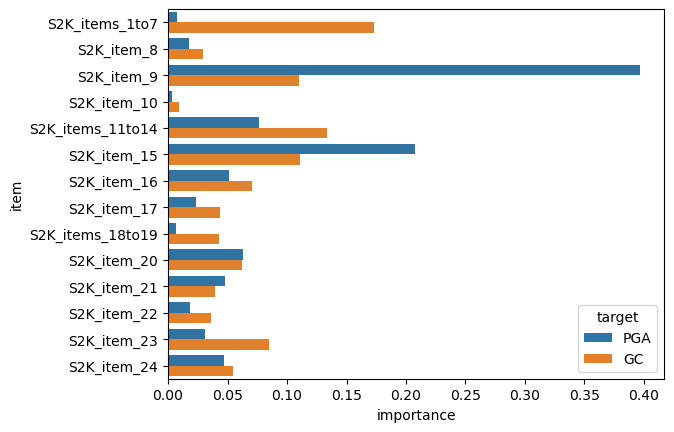

In [144]:
import re

importances_df = pd.DataFrame(regressions()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

sns.barplot(melted,x='importance',y='item', hue='target')


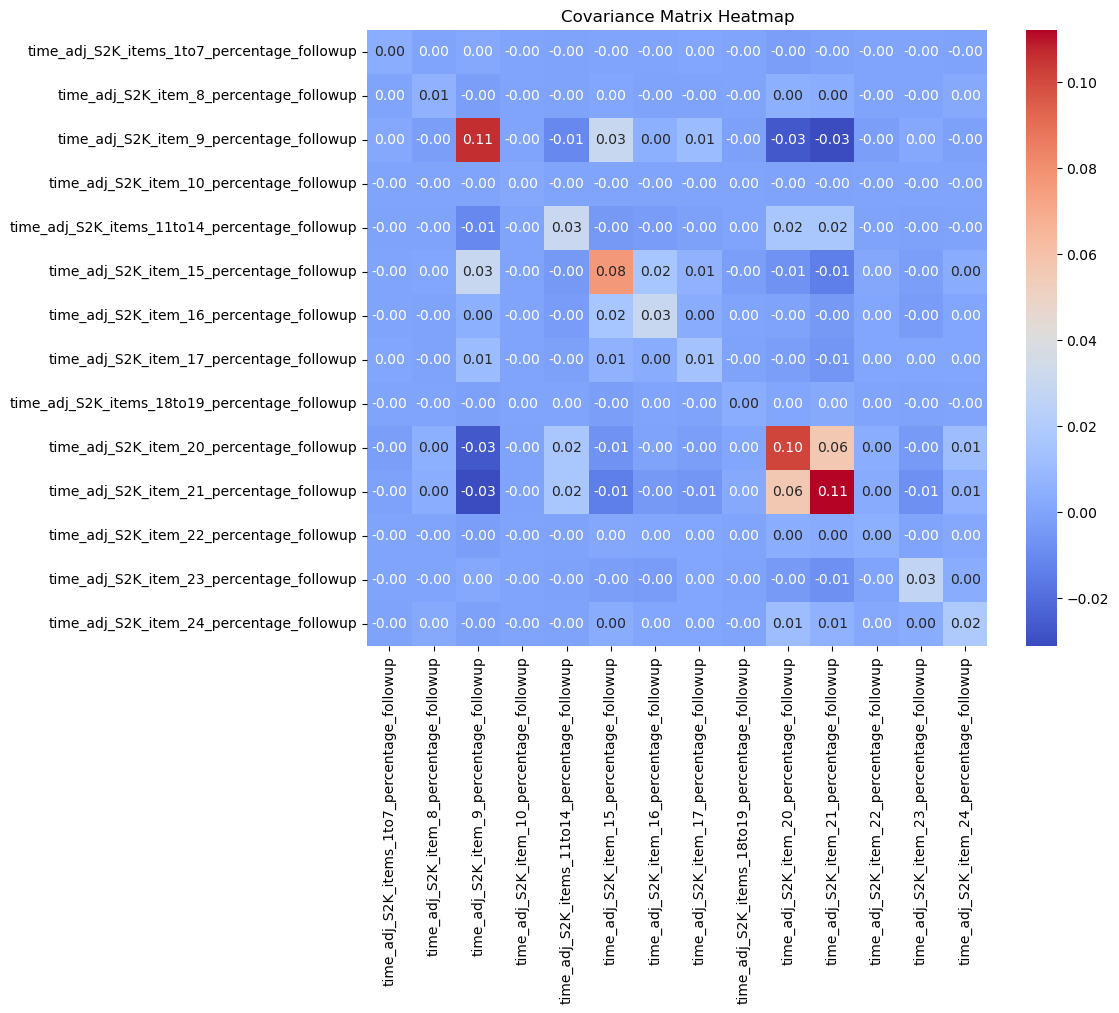

In [ ]:
cov_matrix = np.cov(features, rowvar=False) 


plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=features.columns, yticklabels=features.columns)
plt.title("Covariance Matrix Heatmap")
plt.show()
